In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, f1_score, recall_score, precision_score
from google.colab import drive

# Mount Drive
drive.mount('/content/drive', force_remount=True)

# Define Base Paths
ROOT = "/content/drive/.shortcut-targets-by-id/1-SJqawR0scR6wW5lMAddVjW3uFbULkCX/Bayes_ML_HiddenLayerHeros"
BASE = f"{ROOT}/DeepfakeEval2024"

print(f"Working Directory: {BASE}")



Mounted at /content/drive
Working Directory: /content/drive/.shortcut-targets-by-id/1-SJqawR0scR6wW5lMAddVjW3uFbULkCX/Bayes_ML_HiddenLayerHeros/DeepfakeEval2024


In [5]:
# Model Configuration Map
# Maps display names to file paths and the specific probability column names used in your previous runs
models_config = [
    {
        "name": "Linear (Baseline)",
        "path": f"{BASE}/results/baseline_linear/test_predictions.csv",
        "prob_col": "p_fake",
        "has_uncertainty": False
    },
    {
        "name": "Naive Bayes",
        "path": f"{BASE}/results/baseline_gaussiannb/test_predictions.csv",
        "prob_col": "p_fake",
        "has_uncertainty": False
    },
    {
        "name": "MC Dropout",
        "path": f"{BASE}/results/baseline_mc_dropout/mc_dropout_test_predictions_std.csv",
        "prob_col": "p_fake_mean",
        "has_uncertainty": True,
        "std_col": "p_fake_std"
    },
    {
        "name": "Variational Inference",
        "path": f"{BASE}/results/vi_bayesian_head/test_predictions.csv",
        "prob_col": "p_fake_mean",
        "has_uncertainty": True,
        "std_col": "p_fake_std"
    }
]

In [4]:
def find_optimal_threshold(y_true, y_prob, target_metric='f1'):
    thresholds = np.linspace(0, 1, 1001)
    best_score = -1
    best_thr = 0.5
    best_metrics = {}

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)

        if target_metric == 'f1':
            score = f1_score(y_true, y_pred)
        elif target_metric == 'accuracy':
            score = accuracy_score(y_true, y_pred)
        elif target_metric == 'recall':
            score = recall_score(y_true, y_pred)
        else:
            score = f1_score(y_true, y_pred) # default

        if score > best_score:
            best_score = score
            best_thr = thr
            # Calculate all metrics for this candidate best threshold
            best_metrics = {
                'threshold': thr,
                'accuracy': accuracy_score(y_true, y_pred),
                'f1': f1_score(y_true, y_pred),
                'recall': recall_score(y_true, y_pred),
                'precision': precision_score(y_true, y_pred, zero_division=0),
                'auc': roc_auc_score(y_true, y_prob) # AUC is threshold-independent
            }

    return best_metrics

## F1

In [9]:
# Configuration: Define the target metric for threshold optimization
# Options: 'f1', 'accuracy', 'recall', 'precision'
OPTIMIZATION_TARGET = 'f1'
print(f"Optimization Logic Ready. Target Metric: {OPTIMIZATION_TARGET}")

Optimization Logic Ready. Target Metric: f1


Processing: Linear (Baseline)...
Processing: Naive Bayes...
Processing: MC Dropout...
Processing: Variational Inference...


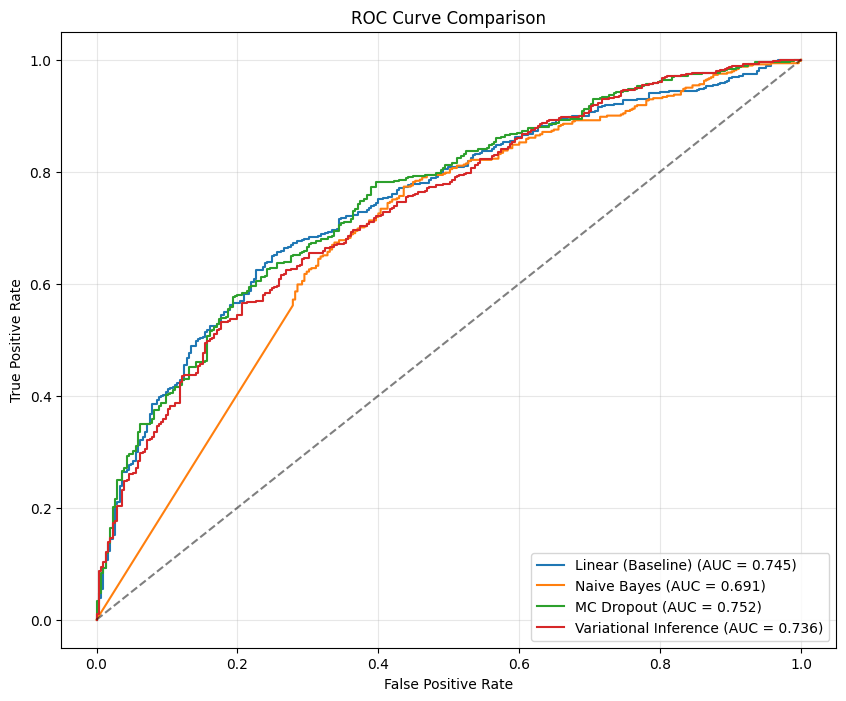


Model Comparison sorted by optimal F1 Score:


,Model,Best Threshold,AUC,Accuracy,F1 Score,Recall,Precision,Uncertainty Gap (Wrong - Correct)
3,Variational Inference,0.112,0.735674,0.676845,0.781787,0.945946,0.666179,0.044591
2,MC Dropout,0.015,0.751604,0.679389,0.781629,0.937630,0.670134,0.028760
0,Linear (Baseline),0.148,0.745401,0.680662,0.774077,0.893971,0.682540,NaN
1,Naive Bayes,0.000,0.691084,0.611959,0.759274,1.000000,0.611959,NaN


In [8]:
results = []
plt.figure(figsize=(10, 8))

for config in models_config:
    if os.path.exists(config['path']):
        print(f"Processing: {config['name']}...")

        # Load Data
        df = pd.read_csv(config['path'])

        # Extract Truth and Probabilities
        y_true = df['y_true'].values
        y_prob = df[config['prob_col']].values

        # Find Optimal Metrics
        metrics = find_optimal_threshold(y_true, y_prob, target_metric=OPTIMIZATION_TARGET)

        # Append to results
        res_entry = {
            'Model': config['name'],
            'Best Threshold': metrics['threshold'],
            'AUC': metrics['auc'],
            'Accuracy': metrics['accuracy'],
            'F1 Score': metrics['f1'],
            'Recall': metrics['recall'],
            'Precision': metrics['precision']
        }

        # Add Uncertainty Metric if available (Mean Uncertainty for wrong predictions vs correct)
        if config['has_uncertainty']:
            std_col = config['std_col']
            if std_col in df.columns:
                # Calculate uncertainty gap
                y_pred_opt = (y_prob >= metrics['threshold']).astype(int)
                wrong_mask = y_pred_opt != y_true
                mean_std_wrong = df.loc[wrong_mask, std_col].mean()
                mean_std_correct = df.loc[~wrong_mask, std_col].mean()
                res_entry['Uncertainty Gap (Wrong - Correct)'] = mean_std_wrong - mean_std_correct
        else:
            res_entry['Uncertainty Gap (Wrong - Correct)'] = np.nan

        results.append(res_entry)

        # Add to ROC Plot
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        plt.plot(fpr, tpr, label=f"{config['name']} (AUC = {metrics['auc']:.3f})")

    else:
        print(f"Warning: File not found for {config['name']} at {config['path']}")

# Finalize Plot
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Display Comparison Table
results_df = pd.DataFrame(results)
# Formatting for cleaner display
text_label_map = {'f1': 'F1 Score', 'accuracy': 'Accuracy', 'recall': 'Recall'}
# Sort by the target metric
results_df = results_df.sort_values(by=text_label_map.get(OPTIMIZATION_TARGET, 'F1 Score'), ascending=False)

print(f"\nModel Comparison sorted by optimal {text_label_map.get(OPTIMIZATION_TARGET, 'Metric')}:")
display(results_df)

## Accuracy

In [12]:
# Configuration: Define the target metric for threshold optimization
# Options: 'f1', 'accuracy', 'recall', 'precision'
OPTIMIZATION_TARGET = 'accuracy'
print(f"Optimization Logic Ready. Target Metric: {OPTIMIZATION_TARGET}")

Optimization Logic Ready. Target Metric: accuracy


Processing: Linear (Baseline)...
Processing: Naive Bayes...
Processing: MC Dropout...
Processing: Variational Inference...


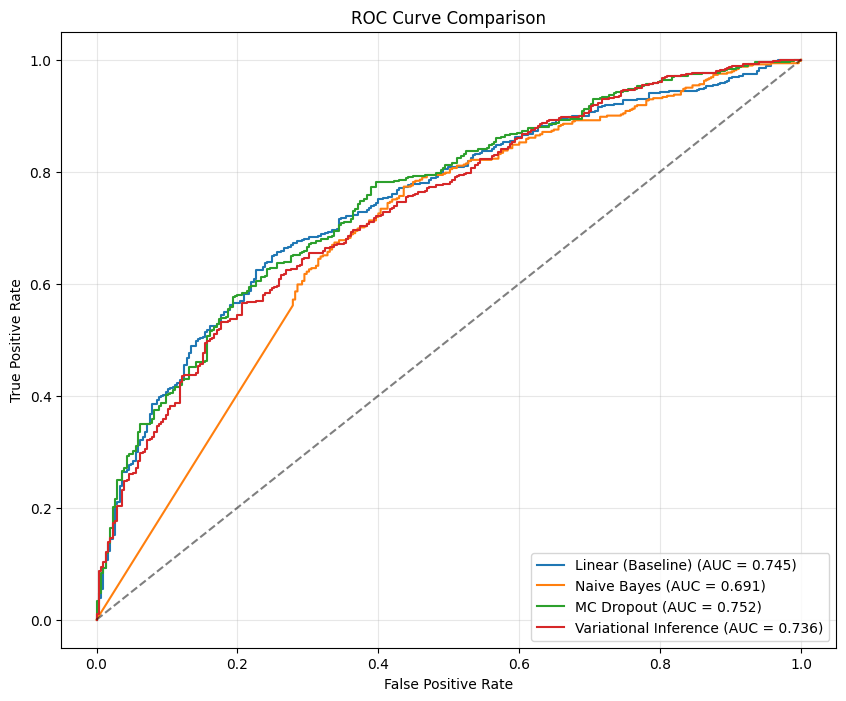


Model Comparison sorted by optimal Accuracy:


,Model,Best Threshold,AUC,Accuracy,F1 Score,Recall,Precision,Uncertainty Gap (Wrong - Correct)
2,MC Dropout,0.516,0.751604,0.712468,0.768916,0.781705,0.756539,0.020053
0,Linear (Baseline),0.337,0.745401,0.693384,0.754832,0.771310,0.739044,NaN
3,Variational Inference,0.204,0.735674,0.685751,0.775658,0.887734,0.688710,0.045733
1,Naive Bayes,0.001,0.691084,0.671756,0.725532,0.708940,0.742919,NaN


In [13]:
results = []
plt.figure(figsize=(10, 8))

for config in models_config:
    if os.path.exists(config['path']):
        print(f"Processing: {config['name']}...")

        # Load Data
        df = pd.read_csv(config['path'])

        # Extract Truth and Probabilities
        y_true = df['y_true'].values
        y_prob = df[config['prob_col']].values

        # Find Optimal Metrics
        metrics = find_optimal_threshold(y_true, y_prob, target_metric=OPTIMIZATION_TARGET)

        # Append to results
        res_entry = {
            'Model': config['name'],
            'Best Threshold': metrics['threshold'],
            'AUC': metrics['auc'],
            'Accuracy': metrics['accuracy'],
            'F1 Score': metrics['f1'],
            'Recall': metrics['recall'],
            'Precision': metrics['precision']
        }

        # Add Uncertainty Metric if available (Mean Uncertainty for wrong predictions vs correct)
        if config['has_uncertainty']:
            std_col = config['std_col']
            if std_col in df.columns:
                # Calculate uncertainty gap
                y_pred_opt = (y_prob >= metrics['threshold']).astype(int)
                wrong_mask = y_pred_opt != y_true
                mean_std_wrong = df.loc[wrong_mask, std_col].mean()
                mean_std_correct = df.loc[~wrong_mask, std_col].mean()
                res_entry['Uncertainty Gap (Wrong - Correct)'] = mean_std_wrong - mean_std_correct
        else:
            res_entry['Uncertainty Gap (Wrong - Correct)'] = np.nan

        results.append(res_entry)

        # Add to ROC Plot
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        plt.plot(fpr, tpr, label=f"{config['name']} (AUC = {metrics['auc']:.3f})")

    else:
        print(f"Warning: File not found for {config['name']} at {config['path']}")

# Finalize Plot
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Display Comparison Table
results_df = pd.DataFrame(results)
# Formatting for cleaner display
text_label_map = {'f1': 'F1 Score', 'accuracy': 'Accuracy', 'recall': 'Recall'}
# Sort by the target metric
results_df = results_df.sort_values(by=text_label_map.get(OPTIMIZATION_TARGET, 'F1 Score'), ascending=False)

print(f"\nModel Comparison sorted by optimal {text_label_map.get(OPTIMIZATION_TARGET, 'Metric')}:")
display(results_df)

## Recall (Meaningless)

In [14]:
# Configuration: Define the target metric for threshold optimization
# Options: 'f1', 'accuracy', 'recall', 'precision'
OPTIMIZATION_TARGET = 'recall'
print(f"Optimization Logic Ready. Target Metric: {OPTIMIZATION_TARGET}")

Optimization Logic Ready. Target Metric: recall


Processing: Linear (Baseline)...
Processing: Naive Bayes...
Processing: MC Dropout...
Processing: Variational Inference...


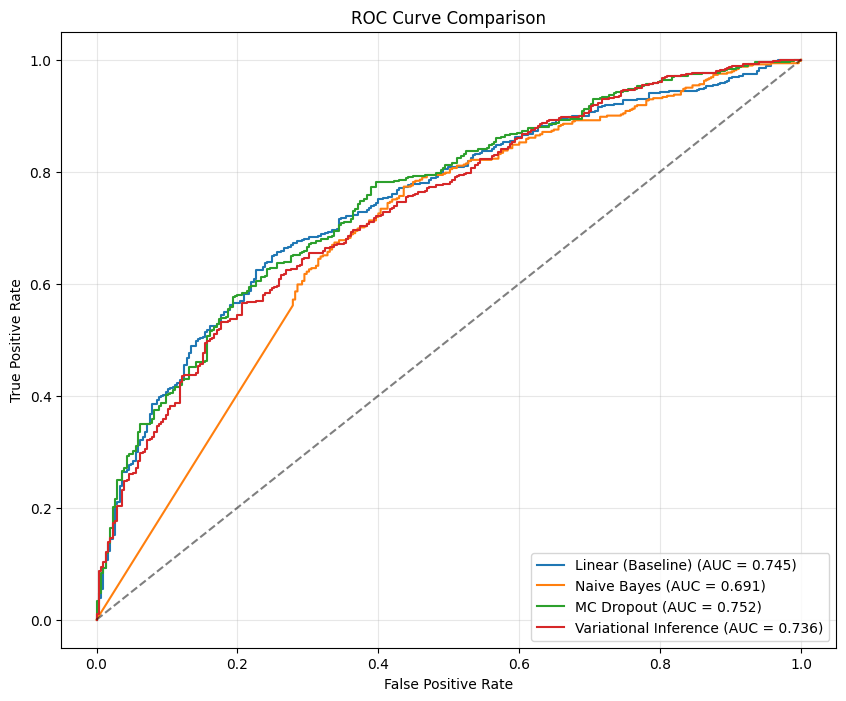


Model Comparison sorted by optimal Recall:


,Model,Best Threshold,AUC,Accuracy,F1 Score,Recall,Precision,Uncertainty Gap (Wrong - Correct)
0,Linear (Baseline),0.0,0.745401,0.611959,0.759274,1.0,0.611959,NaN
1,Naive Bayes,0.0,0.691084,0.611959,0.759274,1.0,0.611959,NaN
2,MC Dropout,0.0,0.751604,0.611959,0.759274,1.0,0.611959,0.013434
3,Variational Inference,0.0,0.735674,0.611959,0.759274,1.0,0.611959,-0.004580


In [15]:
results = []
plt.figure(figsize=(10, 8))

for config in models_config:
    if os.path.exists(config['path']):
        print(f"Processing: {config['name']}...")

        # Load Data
        df = pd.read_csv(config['path'])

        # Extract Truth and Probabilities
        y_true = df['y_true'].values
        y_prob = df[config['prob_col']].values

        # Find Optimal Metrics
        metrics = find_optimal_threshold(y_true, y_prob, target_metric=OPTIMIZATION_TARGET)

        # Append to results
        res_entry = {
            'Model': config['name'],
            'Best Threshold': metrics['threshold'],
            'AUC': metrics['auc'],
            'Accuracy': metrics['accuracy'],
            'F1 Score': metrics['f1'],
            'Recall': metrics['recall'],
            'Precision': metrics['precision']
        }

        # Add Uncertainty Metric if available (Mean Uncertainty for wrong predictions vs correct)
        if config['has_uncertainty']:
            std_col = config['std_col']
            if std_col in df.columns:
                # Calculate uncertainty gap
                y_pred_opt = (y_prob >= metrics['threshold']).astype(int)
                wrong_mask = y_pred_opt != y_true
                mean_std_wrong = df.loc[wrong_mask, std_col].mean()
                mean_std_correct = df.loc[~wrong_mask, std_col].mean()
                res_entry['Uncertainty Gap (Wrong - Correct)'] = mean_std_wrong - mean_std_correct
        else:
            res_entry['Uncertainty Gap (Wrong - Correct)'] = np.nan

        results.append(res_entry)

        # Add to ROC Plot
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        plt.plot(fpr, tpr, label=f"{config['name']} (AUC = {metrics['auc']:.3f})")

    else:
        print(f"Warning: File not found for {config['name']} at {config['path']}")

# Finalize Plot
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Display Comparison Table
results_df = pd.DataFrame(results)
# Formatting for cleaner display
text_label_map = {'f1': 'F1 Score', 'accuracy': 'Accuracy', 'recall': 'Recall'}
# Sort by the target metric
results_df = results_df.sort_values(by=text_label_map.get(OPTIMIZATION_TARGET, 'F1 Score'), ascending=False)

print(f"\nModel Comparison sorted by optimal {text_label_map.get(OPTIMIZATION_TARGET, 'Metric')}:")
display(results_df)

## Precision

In [28]:
# Configuration: Define the target metric for threshold optimization
# Options: 'f1', 'accuracy', 'recall', 'precision'
OPTIMIZATION_TARGET = 'precision'
print(f"Optimization Logic Ready. Target Metric: {OPTIMIZATION_TARGET}")

Optimization Logic Ready. Target Metric: precision


Processing: Linear (Baseline)...
Processing: Naive Bayes...
Processing: MC Dropout...
Processing: Variational Inference...


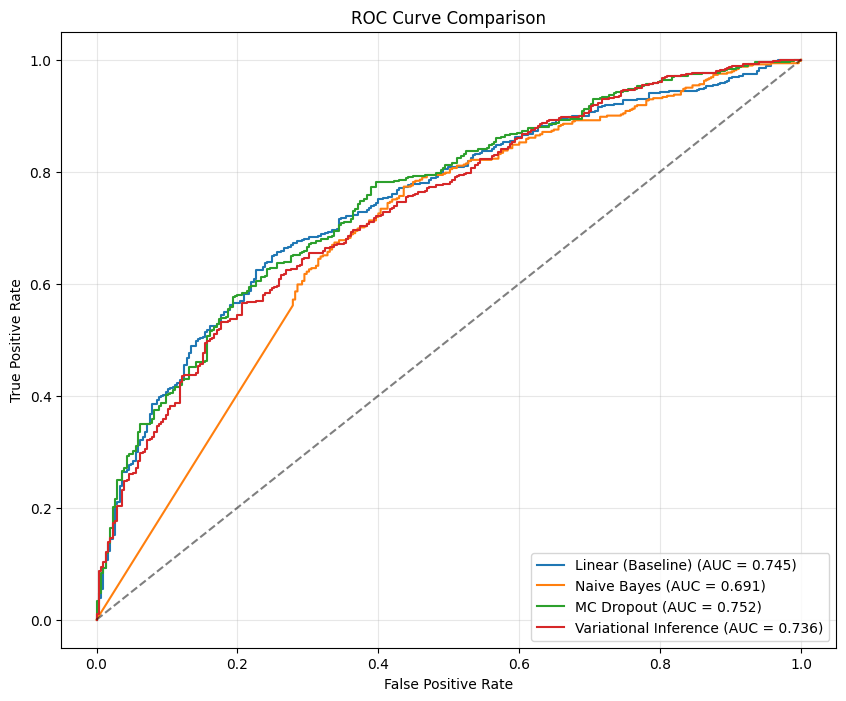


Model Comparison sorted by optimal Metric:


In [30]:
results = []
plt.figure(figsize=(10, 8))

for config in models_config:
    if os.path.exists(config['path']):
        print(f"Processing: {config['name']}...")

        # Load Data
        df = pd.read_csv(config['path'])

        # Extract Truth and Probabilities
        y_true = df['y_true'].values
        y_prob = df[config['prob_col']].values

        # Find Optimal Metrics
        metrics = find_optimal_threshold(y_true, y_prob, target_metric=OPTIMIZATION_TARGET)

        # Append to results
        res_entry = {
            'Model': config['name'],
            'Best Threshold': metrics['threshold'],
            'AUC': metrics['auc'],
            'Accuracy': metrics['accuracy'],
            'F1 Score': metrics['f1'],
            'Recall': metrics['recall'],
            'Precision': metrics['precision']
        }

        # Add Uncertainty Metric if available (Mean Uncertainty for wrong predictions vs correct)
        if config['has_uncertainty']:
            std_col = config['std_col']
            if std_col in df.columns:
                # Calculate uncertainty gap
                y_pred_opt = (y_prob >= metrics['threshold']).astype(int)
                wrong_mask = y_pred_opt != y_true
                mean_std_wrong = df.loc[wrong_mask, std_col].mean()
                mean_std_correct = df.loc[~wrong_mask, std_col].mean()
                res_entry['Uncertainty Gap (Wrong - Correct)'] = mean_std_wrong - mean_std_correct
        else:
            res_entry['Uncertainty Gap (Wrong - Correct)'] = np.nan

        results.append(res_entry)

        # Add to ROC Plot
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        plt.plot(fpr, tpr, label=f"{config['name']} (AUC = {metrics['auc']:.3f})")

    else:
        print(f"Warning: File not found for {config['name']} at {config['path']}")

# Finalize Plot
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Display Comparison Table
results_df = pd.DataFrame(results)
# Formatting for cleaner display
text_label_map = {'f1': 'F1 Score', 'accuracy': 'Accuracy', 'recall': 'Recall'}
# Sort by the target metric
results_df = results_df.sort_values(by=text_label_map.get(OPTIMIZATION_TARGET, 'F1 Score'), ascending=False)

print(f"\nModel Comparison sorted by optimal {text_label_map.get(OPTIMIZATION_TARGET, 'Metric')}:")

# Other

/tmp/ipykernel_244/3164695736.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([correct_std, wrong_std], labels=['Correct', 'Wrong'], patch_artist=True)
/tmp/ipykernel_244/3164695736.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([correct_std, wrong_std], labels=['Correct', 'Wrong'], patch_artist=True)


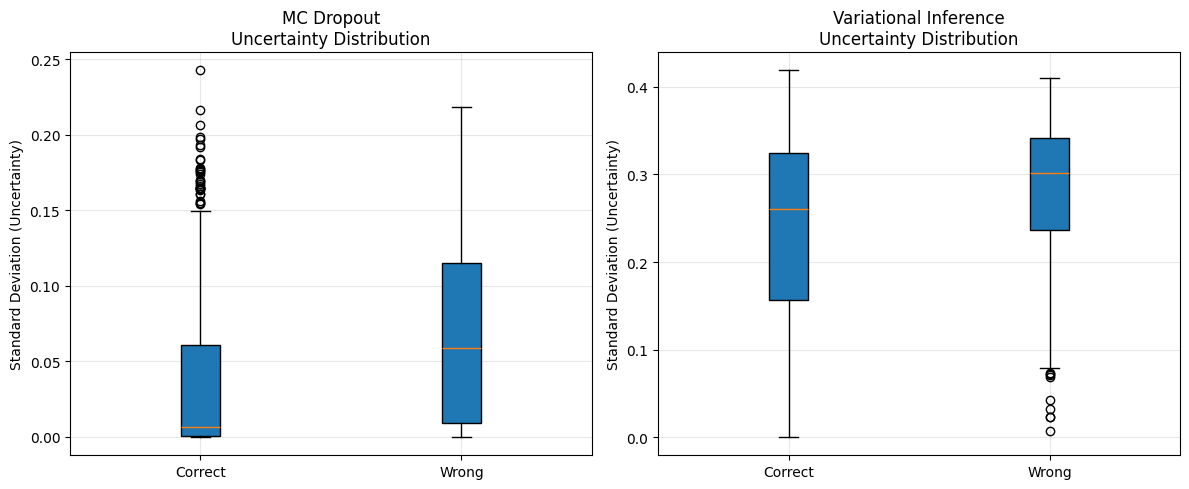

In [18]:
# Filter results for models that have uncertainty data
bayesian_models = [m for m in models_config if m['has_uncertainty']]

if bayesian_models:
    fig, axes = plt.subplots(1, len(bayesian_models), figsize=(12, 5))
    if len(bayesian_models) == 1: axes = [axes] # Handle single case

    for idx, config in enumerate(bayesian_models):
        if os.path.exists(config['path']):
            df = pd.read_csv(config['path'])
            y_true = df['y_true'].values
            y_prob = df[config['prob_col']].values
            y_std  = df[config['std_col']].values

            # Use 0.5 or the optimized threshold found previously
            # Here we recalculate optimized for isolation
            metrics = find_optimal_threshold(y_true, y_prob, target_metric=OPTIMIZATION_TARGET)
            thr = metrics['threshold']

            y_pred = (y_prob >= thr).astype(int)

            # Separation of correct vs wrong
            correct_std = y_std[y_pred == y_true]
            wrong_std = y_std[y_pred != y_true]

            # Boxplot
            ax = axes[idx]
            ax.boxplot([correct_std, wrong_std], labels=['Correct', 'Wrong'], patch_artist=True)
            ax.set_title(f"{config['name']}\nUncertainty Distribution")
            ax.set_ylabel("Standard Deviation (Uncertainty)")
            ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No Bayesian models found or files missing.")

# Deployment